### Smart premium project

##### Step 1: Understanding the Data

##### 1.1 Load and Explore the Dataset

In [1]:
#importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

In [3]:
#importing sample data
df_sample = pd.read_csv('/Users/pavankalyankarri/Desktop/Guvi/Project 3/sample_submission.csv',index_col = 0)
df_sample.head()

,Premium Amount
id,
1200000,1102.545
1200001,1102.545
1200002,1102.545
1200003,1102.545
1200004,1102.545


In [7]:
#importing test data
df_test = pd.read_csv('/Users/pavankalyankarri/Desktop/Guvi/Project 3/test.csv',index_col = 0)
df_test.head()


,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type
id,,,,,,,,,,,,,,,,,,,
1200000,28.0,Female,2310.0,NaN,4.0,Bachelor's,Self-Employed,7.657981,Rural,Basic,NaN,19.0,NaN,1.0,2023-06-04 15:21:39.245086,Poor,Yes,Weekly,House
1200001,31.0,Female,126031.0,Married,2.0,Master's,Self-Employed,13.381379,Suburban,Premium,NaN,14.0,372.0,8.0,2024-04-22 15:21:39.224915,Good,Yes,Rarely,Apartment
1200002,47.0,Female,17092.0,Divorced,0.0,PhD,Unemployed,24.354527,Urban,Comprehensive,NaN,16.0,819.0,9.0,2023-04-05 15:21:39.134960,Average,Yes,Monthly,Condo
1200003,28.0,Female,30424.0,Divorced,3.0,PhD,Self-Employed,5.136225,Suburban,Comprehensive,1.0,3.0,770.0,5.0,2023-10-25 15:21:39.134960,Poor,Yes,Daily,House
1200004,24.0,Male,10863.0,Divorced,2.0,High School,Unemployed,11.844155,Suburban,Premium,NaN,14.0,755.0,7.0,2021-11-26 15:21:39.259788,Average,No,Weekly,House


In [9]:
#importing train data
df_train = pd.read_csv('/Users/pavankalyankarri/Desktop/Guvi/Project 3/train.csv',index_col = 0)
df_train.head()

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
id,,,,,,,,,,,,,,,,,,,,
0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,Premium,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,Comprehensive,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,Premium,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,Basic,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,Premium,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


###### 1.2 Perform Exploratory Data Analysis (EDA)

In [12]:
# Check shape
print("Shape of training data:")
print(f"Rows: {df_train.shape[0]}, Columns: {df_train.shape[1]}")

# Info: data types + non-null count
print("\nData types and nulls:")
df_train.info()

Shape of training data:
Rows: 1200000, Columns: 20

Data types and nulls:
<class 'pandas.core.frame.DataFrame'>
Index: 1200000 entries, 0 to 1199999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Age                   1181295 non-null  float64
 1   Gender                1200000 non-null  object 
 2   Annual Income         1155051 non-null  float64
 3   Marital Status        1181471 non-null  object 
 4   Number of Dependents  1090328 non-null  float64
 5   Education Level       1200000 non-null  object 
 6   Occupation            841925 non-null   object 
 7   Health Score          1125924 non-null  float64
 8   Location              1200000 non-null  object 
 9   Policy Type           1200000 non-null  object 
 10  Previous Claims       835971 non-null   float64
 11  Vehicle Age           1199994 non-null  float64
 12  Credit Score          1062118 non-null  float64
 13  Insurance Duration

In [14]:
# Count missing values per column
print("\nMissing values per column:")
print(df_train.isnull().sum())


Missing values per column:
Age                      18705
Gender                       0
Annual Income            44949
Marital Status           18529
Number of Dependents    109672
Education Level              0
Occupation              358075
Health Score             74076
Location                     0
Policy Type                  0
Previous Claims         364029
Vehicle Age                  6
Credit Score            137882
Insurance Duration           1
Policy Start Date            0
Customer Feedback        77824
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
dtype: int64


In [16]:
# Describe numeric features
print("\nStatistical summary:")
print(df_train.describe())


Statistical summary:
                Age  Annual Income  Number of Dependents  Health Score  \
count  1.181295e+06   1.155051e+06          1.090328e+06  1.125924e+06   
mean   4.114556e+01   3.274522e+04          2.009934e+00  2.561391e+01   
std    1.353995e+01   3.217951e+04          1.417338e+00  1.220346e+01   
min    1.800000e+01   1.000000e+00          0.000000e+00  2.012237e+00   
25%    3.000000e+01   8.001000e+03          1.000000e+00  1.591896e+01   
50%    4.100000e+01   2.391100e+04          2.000000e+00  2.457865e+01   
75%    5.300000e+01   4.463400e+04          3.000000e+00  3.452721e+01   
max    6.400000e+01   1.499970e+05          4.000000e+00  5.897591e+01   

       Previous Claims   Vehicle Age  Credit Score  Insurance Duration  \
count    835971.000000  1.199994e+06  1.062118e+06        1.199999e+06   
mean          1.002689  9.569889e+00  5.929244e+02        5.018219e+00   
std           0.982840  5.776189e+00  1.499819e+02        2.594331e+00   
min           0

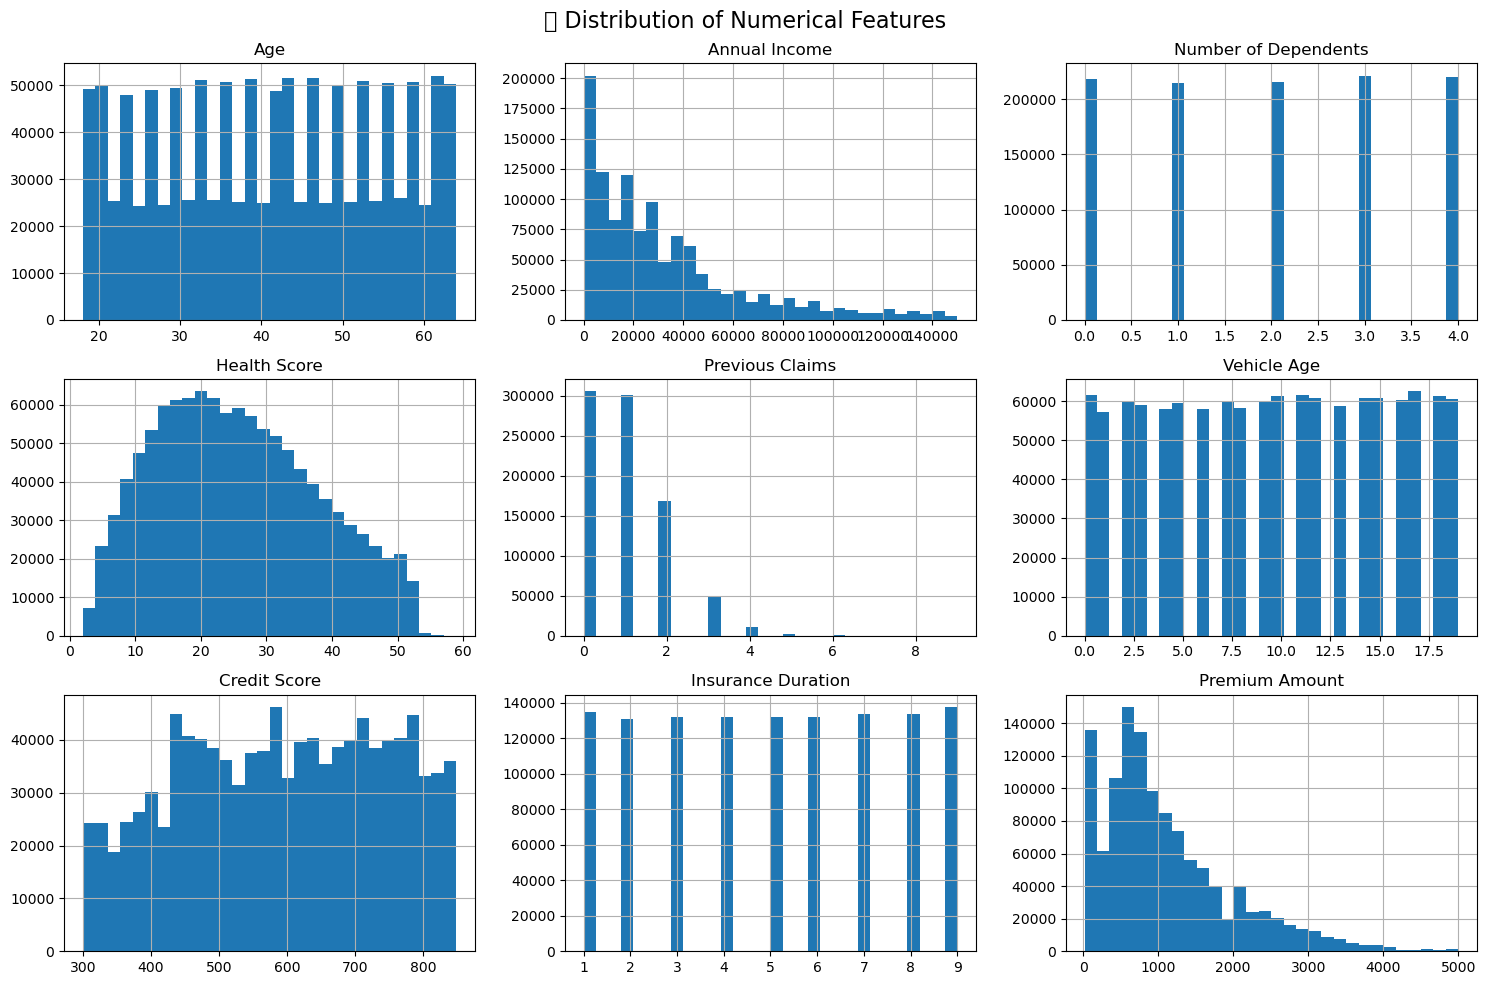

In [18]:
# Plot histograms for all numeric columns
df_train.select_dtypes(include=['int64', 'float64']).hist(bins=30, figsize=(15, 10))
plt.suptitle('📊 Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

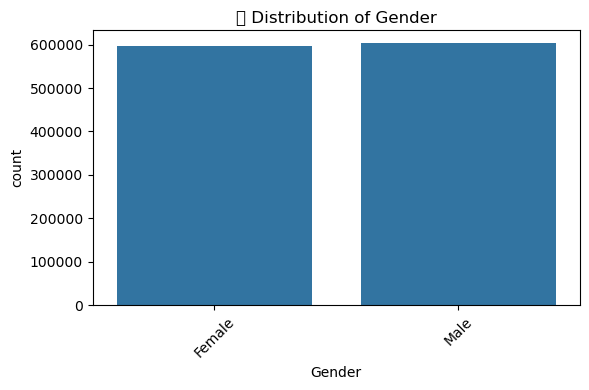

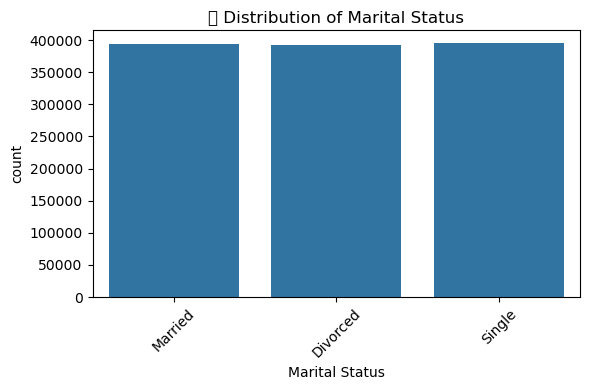

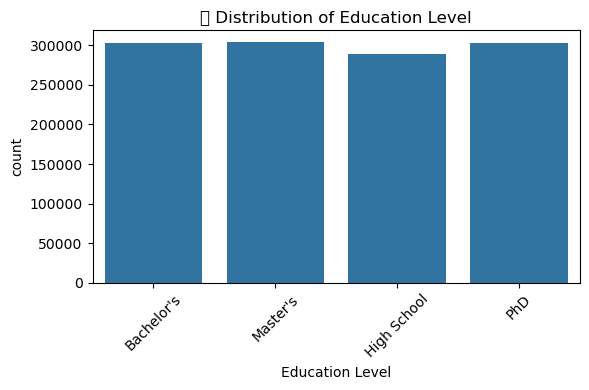

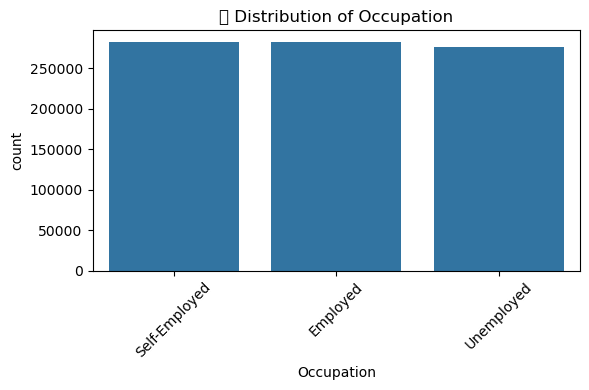

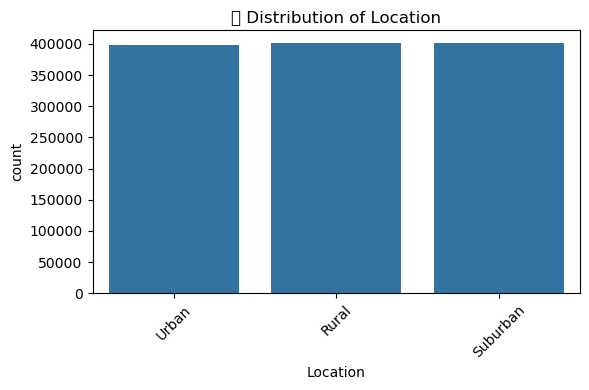

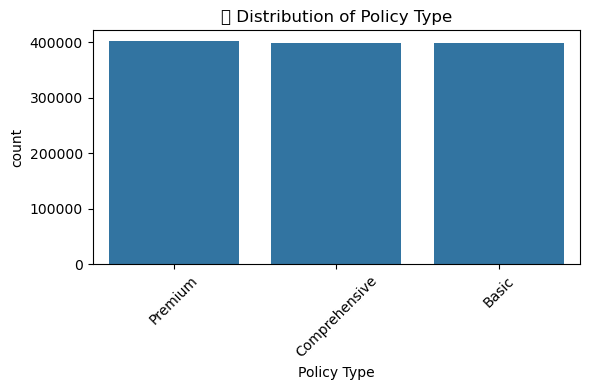

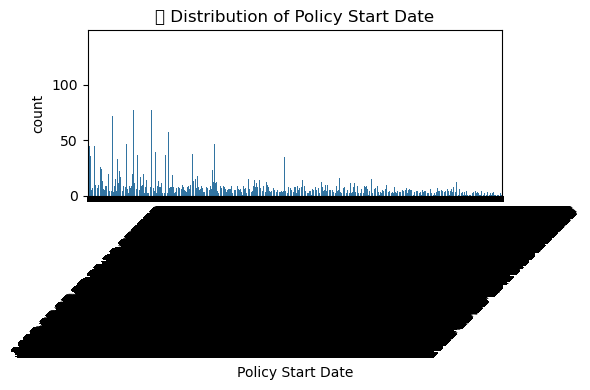

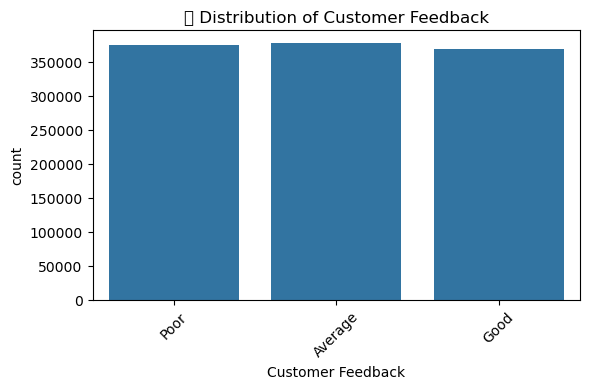

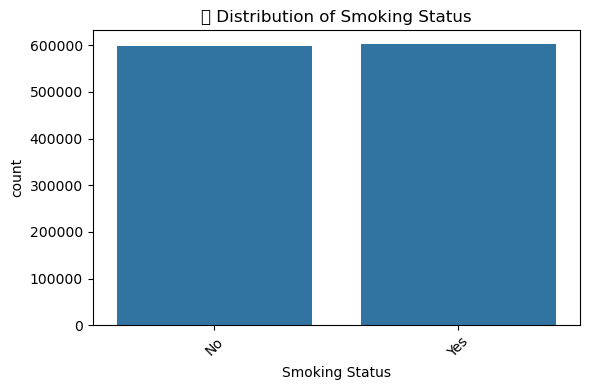

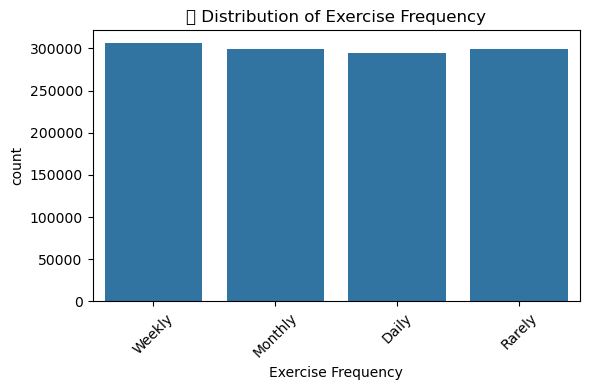

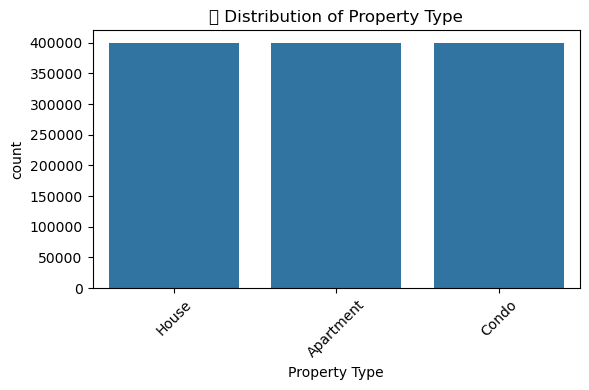

In [57]:
# Get categorical columns
cat_cols = df_train.select_dtypes(include='object').columns

# Plot them one by one
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df_train, x=col)
    plt.title(f"🔤 Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


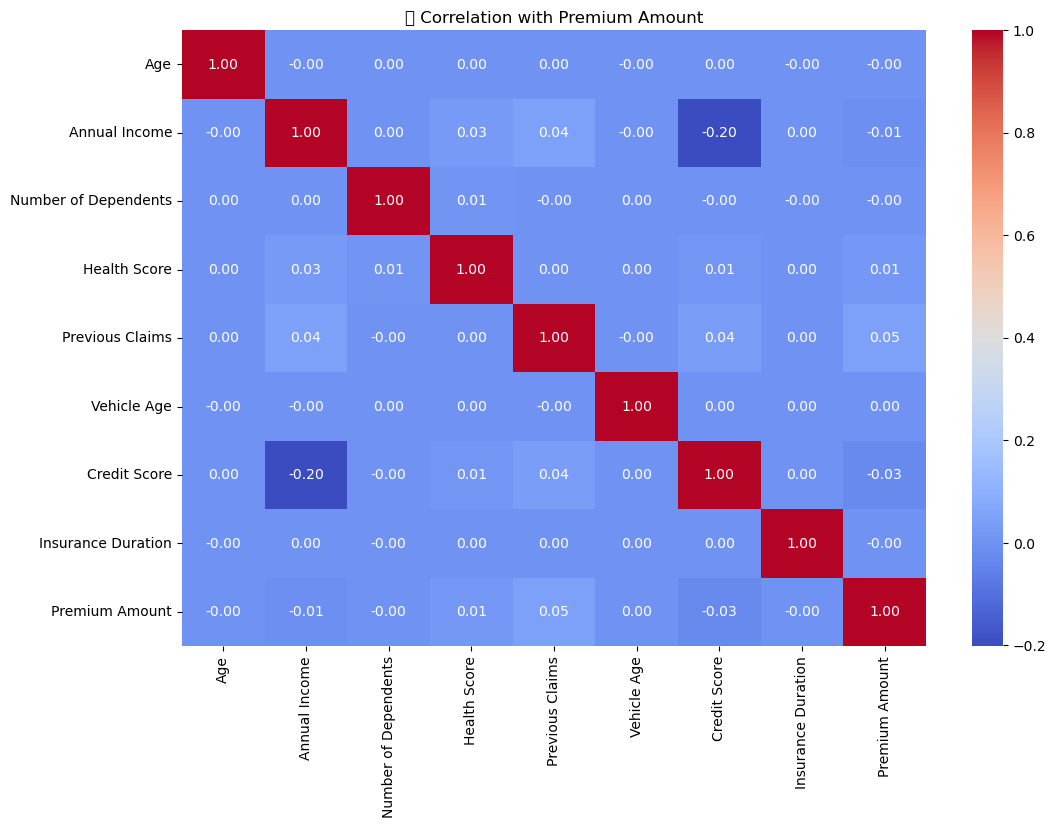

In [23]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df_train.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("🔗 Correlation with Premium Amount")
plt.show()


In [20]:
# 1. Make a copy of training data to preserve original
df_train_clean = df_train.copy()

# 2. Identify numerical and categorical columns
num_cols = df_train_clean.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df_train_clean.select_dtypes(include=['object']).columns

# 3. Fill missing values in numerical columns with median
for col in num_cols:
    if df_train_clean[col].isnull().sum() > 0:
        median_val = df_train_clean[col].median()
        df_train_clean[col].fillna(median_val, inplace=True)
        print(f"✅ Filled missing values in '{col}' with median: {median_val}")

# 4. Fill missing values in categorical columns with mode
for col in cat_cols:
    if df_train_clean[col].isnull().sum() > 0:
        mode_val = df_train_clean[col].mode()[0]
        df_train_clean[col].fillna(mode_val, inplace=True)
        print(f"✅ Filled missing values in '{col}' with mode: {mode_val}")

# 5. Final check
print("\n🔍 Any missing values left?")
print(df_train_clean.isnull().sum().sum())  # should return 0


✅ Filled missing values in 'Age' with median: 41.0
✅ Filled missing values in 'Annual Income' with median: 23911.0
✅ Filled missing values in 'Number of Dependents' with median: 2.0
✅ Filled missing values in 'Health Score' with median: 24.57864816412784
✅ Filled missing values in 'Previous Claims' with median: 1.0
✅ Filled missing values in 'Vehicle Age' with median: 10.0
✅ Filled missing values in 'Credit Score' with median: 595.0
✅ Filled missing values in 'Insurance Duration' with median: 5.0
✅ Filled missing values in 'Marital Status' with mode: Single
✅ Filled missing values in 'Occupation' with mode: Employed
✅ Filled missing values in 'Customer Feedback' with mode: Average

🔍 Any missing values left?
0


In [22]:
# 1. Check how many unique categories each object column has
print("🔍 Unique values in categorical columns:")
for col in cat_cols:
    print(f"{col}: {df_train_clean[col].nunique()}")

# 2. Drop the 'Policy Start Date' column (not useful for now)
df_train_clean.drop('Policy Start Date', axis=1, inplace=True)

# 3. Apply One-Hot Encoding to all categorical columns
df_train_encoded = pd.get_dummies(df_train_clean, drop_first=True)

print("\n✅ After encoding, shape of dataset:")
print(df_train_encoded.shape)

# Check a sample
df_train_encoded.head()


🔍 Unique values in categorical columns:
Gender: 2
Marital Status: 3
Education Level: 4
Occupation: 3
Location: 3
Policy Type: 3
Policy Start Date: 167381
Customer Feedback: 3
Smoking Status: 2
Exercise Frequency: 4
Property Type: 3

✅ After encoding, shape of dataset:
(1200000, 29)


,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount,Gender_Male,...,Policy Type_Comprehensive,Policy Type_Premium,Customer Feedback_Good,Customer Feedback_Poor,Smoking Status_Yes,Exercise Frequency_Monthly,Exercise Frequency_Rarely,Exercise Frequency_Weekly,Property Type_Condo,Property Type_House
id,,,,,,,,,,,,,,,,,,,,,
0,19.0,10049.0,1.0,22.598761,2.0,17.0,372.0,5.0,2869.0,False,...,False,True,False,True,False,False,False,True,False,True
1,39.0,31678.0,3.0,15.569731,1.0,12.0,694.0,2.0,1483.0,False,...,True,False,False,False,True,True,False,False,False,True
2,23.0,25602.0,3.0,47.177549,1.0,14.0,595.0,3.0,567.0,True,...,False,True,True,False,True,False,False,True,False,True
3,21.0,141855.0,2.0,10.938144,1.0,0.0,367.0,1.0,765.0,True,...,False,False,False,True,True,False,False,False,False,False
4,21.0,39651.0,1.0,20.376094,0.0,8.0,598.0,4.0,2022.0,True,...,False,True,False,True,True,False,False,True,False,True


In [24]:
from sklearn.model_selection import train_test_split

# 1. Separate target and features
X = df_train_encoded.drop('Premium Amount', axis=1)
y = df_train_encoded['Premium Amount']

# 2. Split into train and test
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data split completed:")
print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")


✅ Data split completed:
Training set: (960000, 28), (960000,)
Validation set: (240000, 28), (240000,)


In [26]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize scaler
scaler = StandardScaler()

# 2. Fit only on training data and transform both
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("✅ Feature scaling done.")


✅ Feature scaling done.


### Model 1: Linear Regression

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# RMSLE function
def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

# 1. Train the model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 2. Predict
y_pred_lr = lr_model.predict(X_val_scaled)

# 3. Evaluate
mae_lr = mean_absolute_error(y_val, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))
r2_lr = r2_score(y_val, y_pred_lr)
rmsle_lr = rmsle(y_val, y_pred_lr)

# 4. Print results
print("📊 Linear Regression Performance:")
print(f"MAE   : {mae_lr:.2f}")
print(f"RMSE  : {rmse_lr:.2f}")
print(f"R²    : {r2_lr:.4f}")
print(f"RMSLE : {rmsle_lr:.4f}")


📊 Linear Regression Performance:
MAE   : 667.33
RMSE  : 863.34
R²    : 0.0026
RMSLE : 1.1687


### Model 2: Decision Tree Regressor

In [32]:
from sklearn.tree import DecisionTreeRegressor

# 1. Initialize model with a reasonable depth to prevent overfitting
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train_scaled, y_train)

# 2. Predict
y_pred_dt = dt_model.predict(X_val_scaled)

# 3. Evaluate
mae_dt = mean_absolute_error(y_val, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_val, y_pred_dt))
r2_dt = r2_score(y_val, y_pred_dt)
rmsle_dt = rmsle(y_val, y_pred_dt)

# 4. Print results
print("📊 Decision Tree Performance:")
print(f"MAE   : {mae_dt:.2f}")
print(f"RMSE  : {rmse_dt:.2f}")
print(f"R²    : {r2_dt:.4f}")
print(f"RMSLE : {rmsle_dt:.4f}")


📊 Decision Tree Performance:
MAE   : 643.79
RMSE  : 848.93
R²    : 0.0356
RMSLE : 1.1470


### Model 3: Random Forest

In [35]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# 2. Predict
y_pred_rf = rf_model.predict(X_val_scaled)

# 3. Evaluate
mae_rf = mean_absolute_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf = r2_score(y_val, y_pred_rf)
rmsle_rf = rmsle(y_val, y_pred_rf)

# 4. Print results
print("📊 Random Forest Performance:")
print(f"MAE   : {mae_rf:.2f}")
print(f"RMSE  : {rmse_rf:.2f}")
print(f"R²    : {r2_rf:.4f}")
print(f"RMSLE : {rmsle_rf:.4f}")


📊 Random Forest Performance:
MAE   : 642.65
RMSE  : 846.56
R²    : 0.0410
RMSLE : 1.1463


### Model 4: XGBoost

In [37]:
!pip install xgboost
import xgboost as xgb




In [39]:
# 1. Prepare data in DMatrix format (XGBoost's optimized data structure)
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
dval = xgb.DMatrix(X_val_scaled, label=y_val)

# 2. Set model parameters
params = {
    'objective': 'reg:squarederror',
    'max_depth': 10,
    'eta': 0.1,
    'eval_metric': 'rmse',
    'seed': 42
}

# 3. Train model
xgb_model = xgb.train(params, dtrain, num_boost_round=100)

# 4. Predict
y_pred_xgb = xgb_model.predict(dval)

# 5. Evaluate
mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
r2_xgb = r2_score(y_val, y_pred_xgb)
rmsle_xgb = rmsle(y_val, y_pred_xgb)

# 6. Print results
print("📊 XGBoost Performance:")
print(f"MAE   : {mae_xgb:.2f}")
print(f"RMSE  : {rmse_xgb:.2f}")
print(f"R²    : {r2_xgb:.4f}")
print(f"RMSLE : {rmsle_xgb:.4f}")

📊 XGBoost Performance:
MAE   : 644.61
RMSE  : 847.85
R²    : 0.0381
RMSLE : 1.1479


In [ ]:
'''
📊 📈 Model Performance Summary
Model	MAE	RMSE	R² Score	RMSLE
Linear Reg.	667.33	863.34	0.0026	1.1687
Decision Tree	643.79	848.93	0.0356	1.1470
Random Forest	642.65	846.56	0.0410	1.1463
XGBoost	644.61	847.85	0.0381	1.1479
'''

In [ ]:
'''
✅ Key Takeaways:
Best MAE & RMSE → 🔥 Random Forest

Best R² Score → ✅ Random Forest

Lowest RMSLE → ✅ Random Forest

📌 Even though XGBoost is a powerful model, Random Forest outperformed it slightly on our dataset.

'''

## Building ML Pipeline

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Define pipeline steps
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42))
])

# Fit the pipeline on training data
rf_pipeline.fit(X_train, y_train)

# Predict on validation set
y_pred_pipe = rf_pipeline.predict(X_val)

# Evaluate
mae_pipe = mean_absolute_error(y_val, y_pred_pipe)
rmse_pipe = np.sqrt(mean_squared_error(y_val, y_pred_pipe))
r2_pipe = r2_score(y_val, y_pred_pipe)
rmsle_pipe = rmsle(y_val, y_pred_pipe)

print("📊 Pipeline (Random Forest) Performance:")
print(f"MAE   : {mae_pipe:.2f}")
print(f"RMSE  : {rmse_pipe:.2f}")
print(f"R²    : {r2_pipe:.4f}")
print(f"RMSLE : {rmsle_pipe:.4f}")


📊 Pipeline (Random Forest) Performance:
MAE   : 642.65
RMSE  : 846.56
R²    : 0.0410
RMSLE : 1.1463


## ML Flow

In [43]:
!pip install mlflow


In [45]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("file:///tmp/mlruns")  # 👈 ensures runs go to your visible MLflow UI


# Automatically display MLflow runs in the notebook
mlflow.set_experiment("insurance_premium_prediction")


<Experiment: artifact_location='file:///tmp/mlruns/831797079015474252', creation_time=1753795335441, experiment_id='831797079015474252', last_update_time=1753795335441, lifecycle_stage='active', name='insurance_premium_prediction', tags={}>

In [47]:
with mlflow.start_run():

    # Train the model
    rf_pipeline.fit(X_train, y_train)
    y_pred_pipe = rf_pipeline.predict(X_val)

    # Evaluate
    mae = mean_absolute_error(y_val, y_pred_pipe)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_pipe))
    r2 = r2_score(y_val, y_pred_pipe)
    rmsle_score = rmsle(y_val, y_pred_pipe)

    # Log model parameters
    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 15)

    # Log metrics
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2", r2)
    mlflow.log_metric("RMSLE", rmsle_score)

    # Log the pipeline
    mlflow.sklearn.log_model(rf_pipeline, name="model")

    print("✅ MLflow logging done.")


2025/07/31 08:04:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ MLflow logging done.


### handling Test data now

In [49]:
#filling missing values
df_test["Age"].fillna(df_train["Age"].median(), inplace=True)
df_test["Annual Income"].fillna(df_train["Annual Income"].median(), inplace=True)
df_test["Number of Dependents"].fillna(df_train["Number of Dependents"].median(), inplace=True)
df_test["Health Score"].fillna(df_train["Health Score"].median(), inplace=True)
df_test["Previous Claims"].fillna(df_train["Previous Claims"].median(), inplace=True)
df_test["Vehicle Age"].fillna(df_train["Vehicle Age"].median(), inplace=True)
df_test["Credit Score"].fillna(df_train["Credit Score"].median(), inplace=True)
df_test["Insurance Duration"].fillna(df_train["Insurance Duration"].median(), inplace=True)

df_test["Marital Status"].fillna(df_train["Marital Status"].mode()[0], inplace=True)
df_test["Occupation"].fillna(df_train["Occupation"].mode()[0], inplace=True)
df_test["Customer Feedback"].fillna(df_train["Customer Feedback"].mode()[0], inplace=True)


In [51]:
categorical_cols = ["Gender", "Marital Status", "Education Level", "Occupation", "Location",
                    "Policy Type", "Customer Feedback", "Smoking Status",
                    "Exercise Frequency", "Property Type"]

df_test_encoded = pd.get_dummies(df_test, columns=categorical_cols)

# Align columns with training data
df_test_encoded = df_test_encoded.reindex(columns=X_train.columns, fill_value=0)


In [53]:
predictions = rf_pipeline.predict(df_test_encoded)
output_df = pd.DataFrame({
    "id": df_test_encoded.index,
    "Premium Amount": predictions
})
output_df.to_csv("submission.csv", index=False)
print("✅ Final output file generated: submission.csv")


✅ Final output file generated: submission.csv
